# Analysis

In [39]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import missingno as msno
sns.set_theme(style='darkgrid')
import matplotlib.pyplot as plt

In [40]:
data = pd.read_csv('Assignment/DataSets/preprocessed_data.csv')

In [41]:
data.dtypes

Peso                              float64
Altura                              int64
IMC                               float64
Idade                               int64
Pulsos                             object
SBP                               float64
DBP                               float64
Result SBP-DBP                     object
B2                                 object
Sopro                              object
FC                                float64
HDA1                               object
HDA2                               object
Sexo                               object
Motivo1                            object
Motivo2                            object
Intervalo Idade                    object
Percentil IMC                      object
Systolic Blood Pressure (SBP)      object
Diastolic Blood Pressure (DBP)     object
Patologia                          object
dtype: object

## Bivariate analysis

A **análise bivariada** consiste em analisar exatamente **duas variáveis simultaneamente** para ```determinar se existe uma relação empírica entre elas```.

Ao contrário da análise univariada (que resume apenas uma variável, ex: "qual a média de idades?"), a bivariada tenta responder a perguntas de causa e efeito ou associação, como:

* "O aumento da Idade está relacionado com o aumento da SBP (Pressão Sistólica)?"

* "Existe diferença significativa no IMC entre os diferentes Sexos?"

Existem **três tipos principais de análise bivariada**, dependendo do tipo de dados:

* ```Numérica e Numérica:``` (Ex: Peso vs. Altura). Usa-se **Correlação** e **Regressão Linear**.

* ```Numérica e Categórica:```(Ex: IMC vs. Sexo). Usa-se Boxplots ou testes-T.

* ```Categórica e Categórica:``` (Ex: Sexo vs. Patologia). Usa-se testes Qui-quadrado (Chi-square).

> **Nota:** Neste caso apenas vamos fazer **análise bivariada** para **váriavies Númericas**, porque no enunciado indicou **correlação** e **regressão**

![alt text](img/image-5.PNG)


In [42]:
numeric_features = [
    'Peso', 'Altura', 'IMC', 'Idade', 
    'SBP', 'DBP', 'FC'
]

data_analysis = data[numeric_features]

### Correlation 

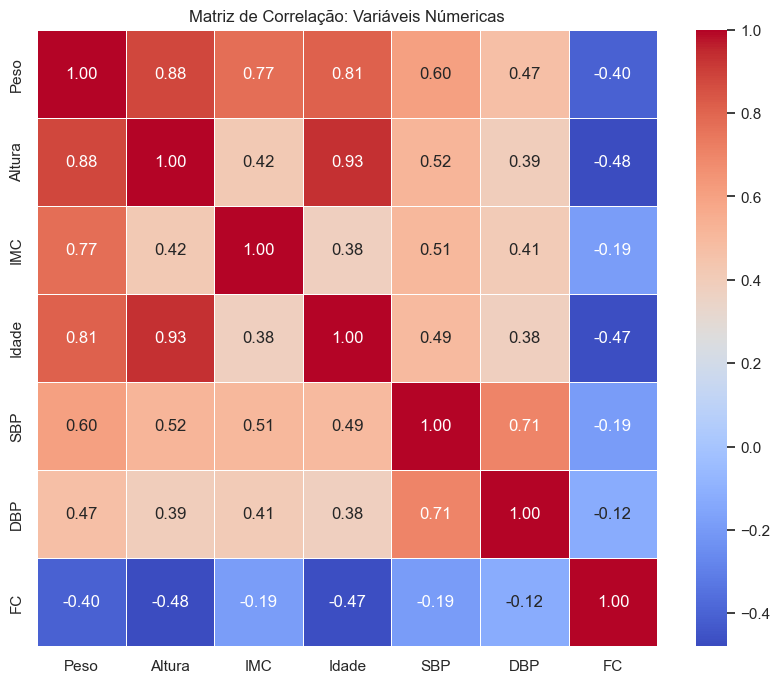

In [43]:
correlation_matrix = data_analysis.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)

plt.title('Matriz de Correlação: Variáveis Númericas')
plt.show()

In [44]:
correlacoes = correlation_matrix.unstack()
correlacoes_ordenadas = correlacoes.sort_values(ascending=False)
correlacoes_positivas = correlacoes_ordenadas[(correlacoes_ordenadas < 1) & (correlacoes_ordenadas > 0.75)]
df_corr_pos = pd.DataFrame(correlacoes_positivas, columns=['Correlação'])
df_corr_pos = df_corr_pos.drop_duplicates()
print("Par de varíavies que estão altamente correlacionadas >0.75 (estão a fornecer a mesma informação)")
print(df_corr_pos)

Par de varíavies que estão altamente correlacionadas >0.75 (estão a fornecer a mesma informação)
              Correlação
Altura Idade    0.932452
       Peso     0.879230
Idade  Peso     0.809501
Peso   IMC      0.774259


### Regression

#### Simple regression

<Figure size 800x600 with 0 Axes>

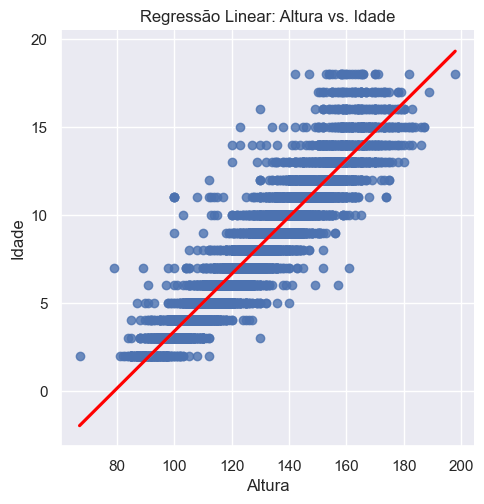

<Figure size 800x600 with 0 Axes>

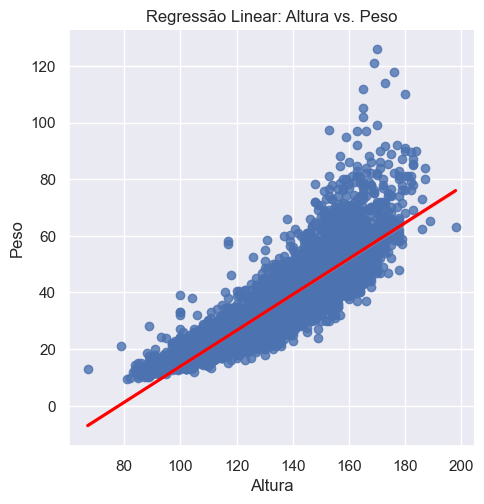

<Figure size 800x600 with 0 Axes>

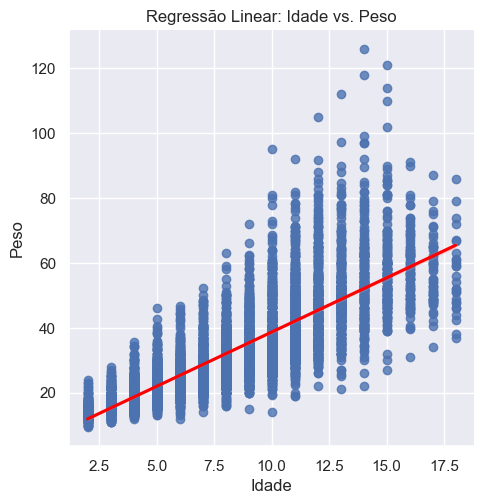

<Figure size 800x600 with 0 Axes>

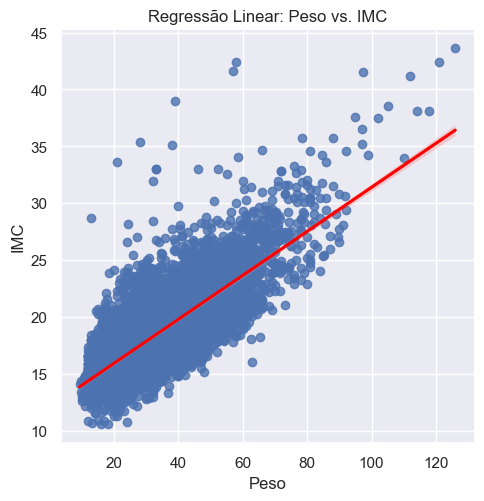

In [45]:
# We only do regression on higly correlated pairs (in this case correlation > 0.75)
highly_correlated_pairs = [['Altura','Idade'],['Altura','Peso'],['Idade','Peso'],['Peso','IMC']]

for p in highly_correlated_pairs:
    f1 = p[0]
    f2 = p[1]
    plt.figure(figsize=(8, 6))
    sns.lmplot(x=f1, y=f2, data=data_analysis, line_kws={'color': 'red'});
    plt.title(f'Regressão Linear: {f1} vs. {f2}')
    plt.show()

#### Statistical Regression

* **R-squared (R²):** Indica a **% da variação** de ```Y```(váriavel dependente) que **é explicada por** ```X``` (váriavel Independente). 
    * Lê-se : "Quero prever ```Y``` com base em ```X```" ou  "```X``` influencia o valor de ```Y```?"
    * e.g R² for 0.30, Y = 'SBP' e X = 'Idade', então a Idade explica 30% da variação de SBP.

* **Coeficiente**(X = Idade e Y=SBP): Se for, por exemplo, 0.5, **significa que por cada 1 ano que a pessoa envelhece, a SBP sobe, em média, 0.5 unidades**.

In [46]:
import statsmodels.api as sm
# Lista corrigida para fazer sentido biológico: [Y (Dependente), X (Independente)]
# Lê-se: "Quero prever Y com base em X" ou "X influencia o valor de Y?"
logical_pairs = [
    ['Altura', 'Idade'],  # Idade influencia a Altura
    ['Peso', 'Altura'],   # Altura influencia o Peso 
    ['Peso', 'Idade'],    # Idade influencia o Peso
    ['IMC', 'Peso']       # Peso influencia o IMC
]

for p in logical_pairs:
    target = p[0]    # Y
    predictor = p[1] # X
    
    print(f"--- Analisando: {target} (Y) vs {predictor} (X) ---")

    Y = data_analysis[target]
    X = data_analysis[predictor]
    X = sm.add_constant(X) 

    modelo = sm.OLS(Y, X).fit()
    print(f"R-squared: {modelo.rsquared:.4f}")
    print(f"Coeficiente: {modelo.params[predictor]:.4f}")
    print("\n")

--- Analisando: Altura (Y) vs Idade (X) ---
R-squared: 0.8695
Coeficiente: 5.3480


--- Analisando: Peso (Y) vs Altura (X) ---
R-squared: 0.7730
Coeficiente: 0.6338


--- Analisando: Peso (Y) vs Idade (X) ---
R-squared: 0.6553
Coeficiente: 3.3469


--- Analisando: IMC (Y) vs Peso (X) ---
R-squared: 0.5995
Coeficiente: 0.1932




"A análise de regressão linear revelou correlações positivas fortes e estatisticamente robustas entre as variáveis.O destaque principal vai para a relação Idade vs. Altura ($R^2 \approx 0.87$), que apresentou o maior poder explicativo do modelo. Observou-se também que, embora a Idade seja um excelente preditor da Altura, ela prediz o Peso com ligeiramente menos precisão ($R^2 \approx 0.65$), o que é esperado dado que o peso sofre maior influência de fatores externos (nutrição/ambiente) do que o crescimento ósseo."

## Multivariate analysis

Multivariate analysis is a powerful technique that allows us to explore relationships between multiple variables simultaneously. It helps uncover hidden patterns and deeper insights that are often missed in univariate or bivariate analyses

### Data preparation

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Definir as listas de features
numeric_features = ['Peso', 'Altura', 'IMC', 'Idade', 'SBP', 'DBP', 'FC']
# Categorias que trazem informação nova (não redundante)
categorical_features = ['Pulsos', 'Result SBP-DBP', 'B2', 'Sopro', 'HDA1', 'HDA2', 'Sexo', 'Motivo1', 'Motivo2'] 

cols_to_use = numeric_features + categorical_features + ['Patologia']
df_clean = data[cols_to_use].dropna()

# --- PREPARAÇÃO DO ALVO (Y) ---
# O y é igual para todos os casos
y = df_clean['Patologia']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes Alvo:", dict(zip(le.classes_, le.transform(le.classes_))))

# Guardar o mapeamento para saberes o que é o quê no final
class_names = list(le.classes_)


# --- CONJUNTO 1: APENAS NUMÉRICO (X_num) ---
# Útil para: K-Means (puro) e Baseline
X_num_raw = df_clean[numeric_features]

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num_raw)
# Variável final para usar: X_num_scaled


# --- CONJUNTO 2: Númerico e Categorico - COMPLETO (X_all) ---
# Útil para: Regressão Múltipla e Mutual Information
X_all_raw = df_clean[numeric_features + categorical_features]

# Aplicar One-Hot Encoding nas categóricas
# drop_first=True reduz a colinearidade (bom para regressão)
X_all_encoded = pd.get_dummies(X_all_raw, columns=categorical_features)

# Escalar tudo (Números originais + Dummies)
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all_encoded)
# Variável final para usar: X_all_scaled


# --- VERIFICAÇÃO ---
print(f"\nLinhas totais (Pacientes): {len(y)}")
print(f"Features no set Numérico (X_num_scaled): {X_num_scaled.shape[1]}")
print(f"Features no set Completo (X_all_scaled): {X_all_scaled.shape[1]}")

Classes Alvo: {'Anormal': np.int64(0), 'Normal': np.int64(1)}

Linhas totais (Pacientes): 6293
Features no set Numérico (X_num_scaled): 7
Features no set Completo (X_all_scaled): 48


### Multiple Linear Regression

* **Análise:** Verificar quais são as varíaveis, que mais influenciam a classificação '''Normal''' ou '''Anormal'''.

#### Creating a  Multiple Linear Regression model

In [48]:

from sklearn.model_selection import train_test_split
# 1. Dividir em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_all_scaled, y_encoded, test_size=0.3, random_state=42)


In [49]:
from sklearn.linear_model import LogisticRegression
# Criar o modelo
# solver='lbfgs' e multi_class='multinomial' são padrão para multiclasse
model = LogisticRegression(max_iter=2000, random_state=42)

# Treinar
model.fit(X_train, y_train)

# Prever no conjunto de teste
y_pred = model.predict(X_test)

#### Performance Analysis

--- Performance da Regressão Múltipla (Logística) ---
              precision    recall  f1-score   support

     Anormal       0.95      0.85      0.90       645
      Normal       0.93      0.98      0.95      1243

    accuracy                           0.93      1888
   macro avg       0.94      0.91      0.93      1888
weighted avg       0.94      0.93      0.93      1888



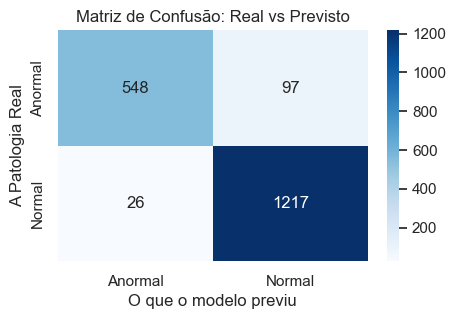

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
# Relatório Estatístico
print("--- Performance da Regressão Múltipla (Logística) ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Visualizar Matriz de Confusão
plt.figure(figsize=(5, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão: Real vs Previsto')
plt.xlabel('O que o modelo previu')
plt.ylabel('A Patologia Real')
plt.show()

#### Coeficient Analysis for both 'Normal' and 'Anormal' pathologies

* Caso 1: ```Se a análise for a classe 'Normal'```


| Coeficiente | O que significa? | Exemplo Prático
| - | - | - |
| **Positivo (+)** | Confirma Saúde. Indica que o paciente está bem. (i.e. maior probabilidade de ter target feature (Patologia) **igual a **Normal**, ou seja, não tem a patologia)  | Ter "Sem Sopro" (+3.0)→ É muito provável ser Normal. |
| **Zero (0)** | Neutro. Não serve para nada. | "Altura" (0.01) → Não ajuda a decidir.| 
| **Negativo (-)** | Indica Doença. Afasta a hipótese de ser saudável.(i.e. maior probabilidade de ter target feature (Patologia) **igual a Anormal, ou seja,  tem a patologia**) | "Sem Sopro" (-3.0) → É muito provável ser Normal."|


>**Nota:** "Coeficientes positivos 'puxam' a decisão para a classe que estamos a analisar. Coeficientes negativos 'empurram' a decisão para a classe oposta."

In [51]:
class_names

['Anormal', 'Normal']

O Scikit-Learn está a calcular coeficientes para a classe: Normal


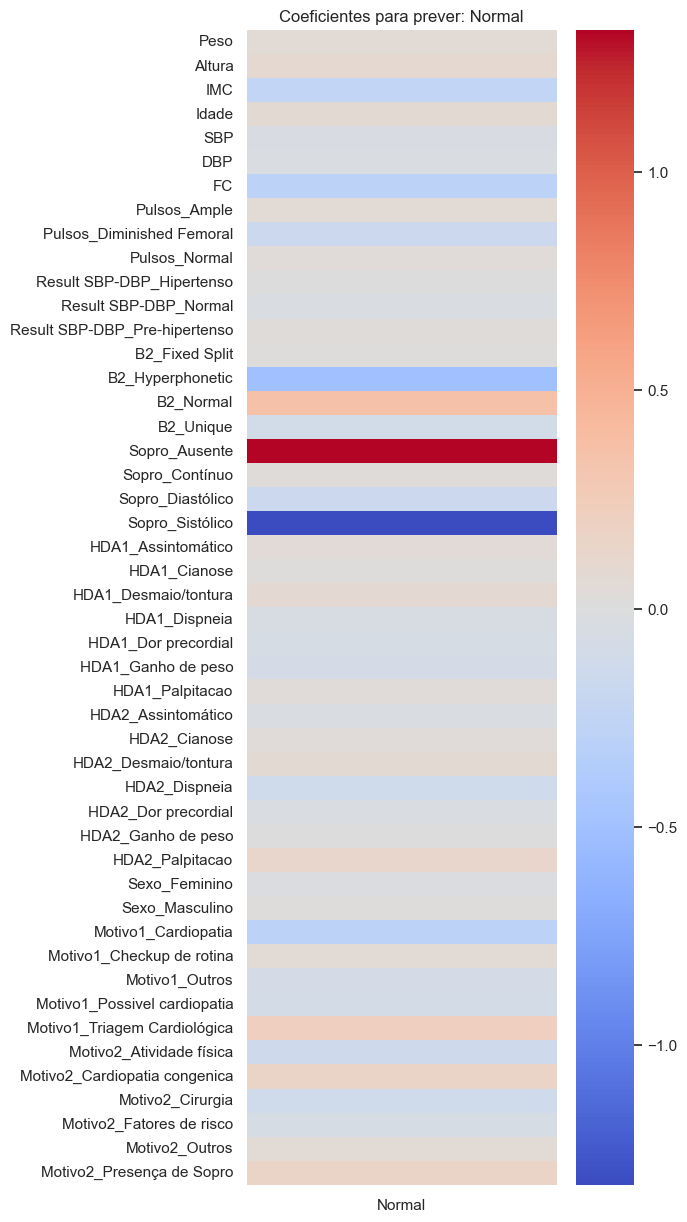


--- O que aumenta a probabilidade de ser 'Normal'? ---
Sopro_Ausente                    1.325904
B2_Normal                        0.362184
Motivo1_Triagem Cardiológica     0.217315
Motivo2_Cardiopatia congenica    0.151848
Motivo2_Presença de Sopro        0.150262
Name: Normal, dtype: float64

--- O que diminui a probabilidade de 'Normal' (logo, indica 'Anormal')? ---
IMC                   -0.244498
FC                    -0.292838
Motivo1_Cardiopatia   -0.293263
B2_Hyperphonetic      -0.513155
Sopro_Sistólico       -1.320056
Name: Normal, dtype: float64


In [ ]:
feature_names = X_all_encoded.columns 

# Verificar qual é a classe positiva (índice 1)
classe_positiva = class_names[1]  # Muito provavelmente é 'Normal'
classe_negativa = class_names[0]  # Muito provavelmente é 'Anormal'

print(f"O Scikit-Learn está a calcular coeficientes para a classe: {classe_positiva}")

coefs_df = pd.DataFrame(model.coef_, columns=feature_names, index=[classe_positiva])
coefs_df = coefs_df.T

# Visualizar
plt.figure(figsize=(5, 15))
sns.heatmap(coefs_df, cmap='coolwarm', center=0, annot=False)
plt.title(f'Coeficientes para prever: {classe_positiva}')
plt.show()

# Análise Corrigida
series_analise = coefs_df.iloc[:,0]
top_features = series_analise.sort_values(ascending=False)

print(f"\n--- O que aumenta a probabilidade de ser '{classe_positiva}'? ---")
print(top_features.head(5))

print(f"\n--- O que diminui a probabilidade de '{classe_positiva}' (logo, indica '{classe_negativa}')? ---")
print(top_features.tail(5))


### Mutual Information (MI)

* **Análise:** As variáveis no topo (com maior score de Mutual Information) são as mais importantes.

#### MI with Categorical and Numerical Features

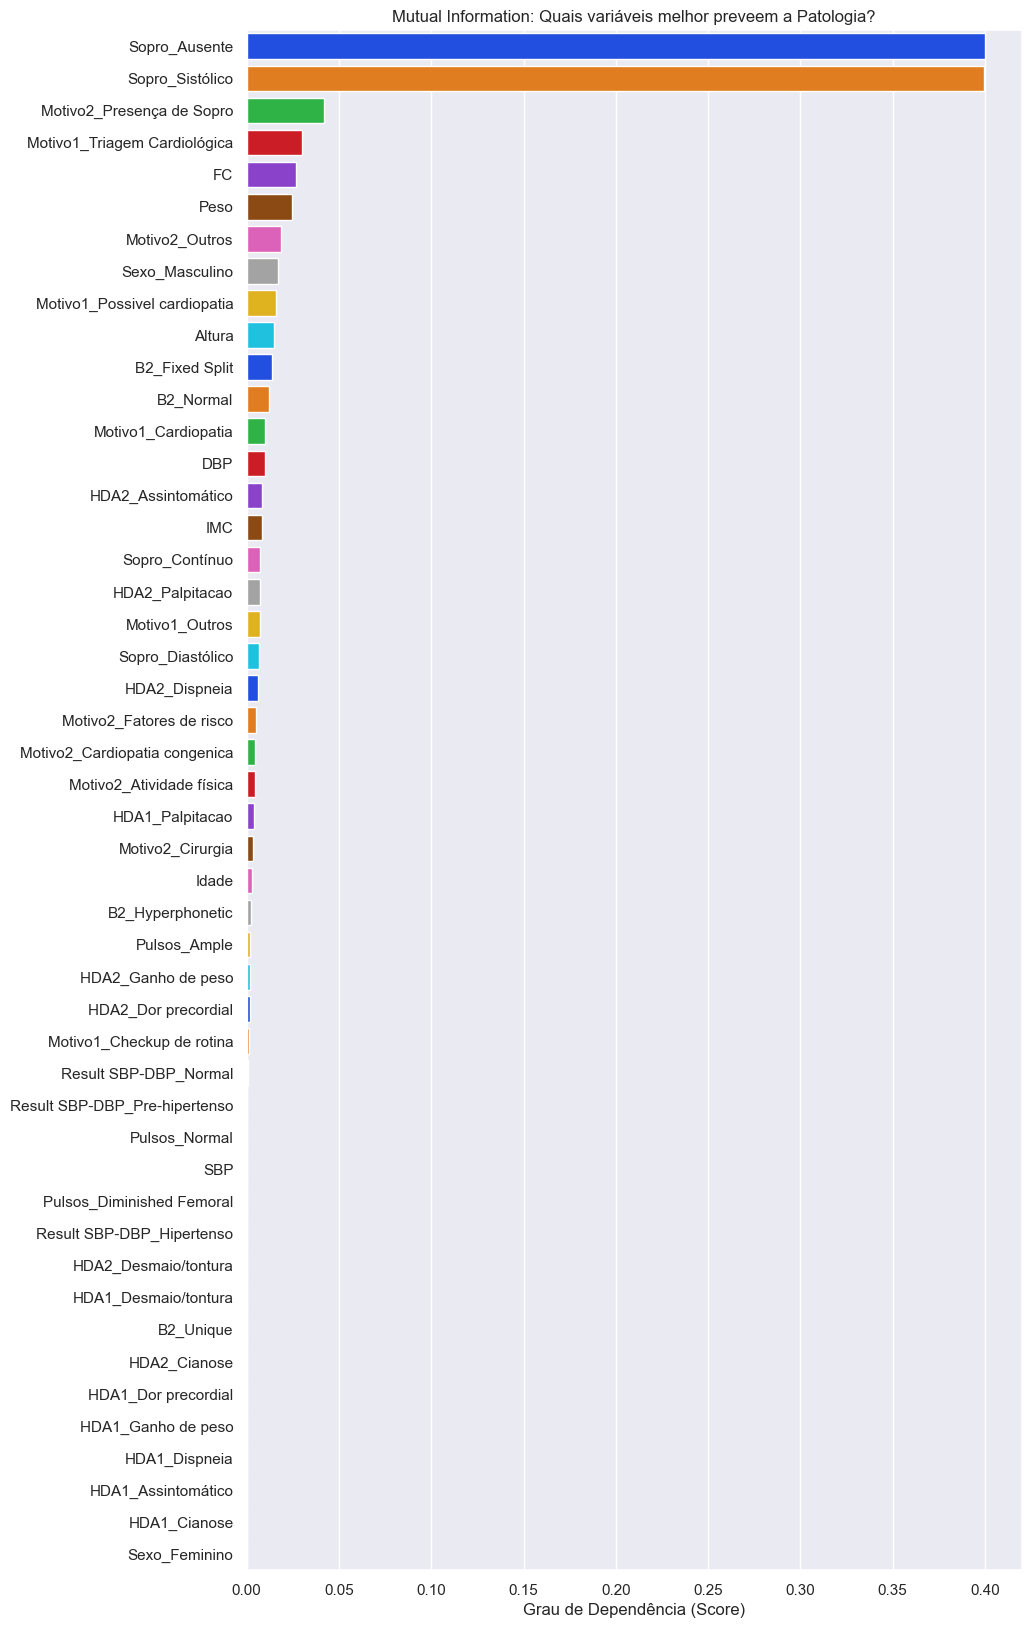

In [53]:
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Calcular a importância
mi_scores = mutual_info_classif(X_all_scaled, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_all_encoded.columns).sort_values(ascending=False)

# Visualizar
plt.figure(figsize=(10, 20))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='bright')
plt.ylabel('')
plt.title('Mutual Information: Quais variáveis melhor preveem a Patologia?')
plt.xlabel('Grau de Dependência (Score)')
plt.show()

#### MI with Numerical Features only

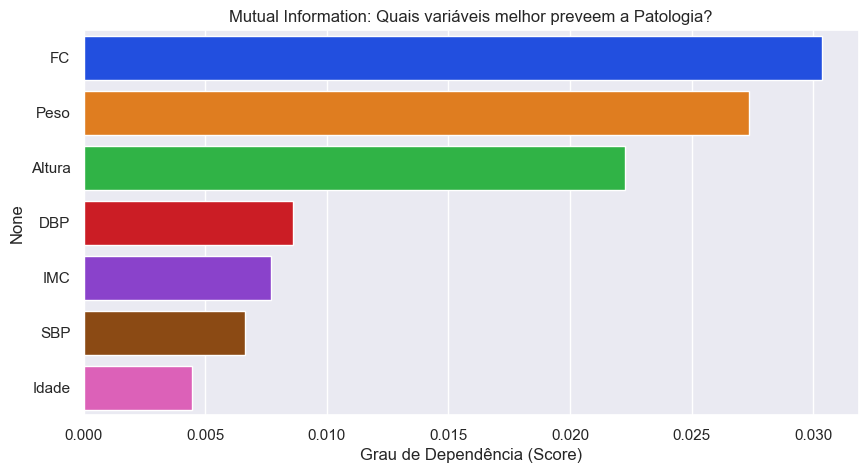

In [54]:
from sklearn.feature_selection import mutual_info_classif

# Calcular a importância
mi_scores = mutual_info_classif(X_num_scaled, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_num_raw.columns).sort_values(ascending=False)

# Visualizar
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='bright')
plt.title('Mutual Information: Quais variáveis melhor preveem a Patologia?')
plt.xlabel('Grau de Dependência (Score)')
plt.show()

### KMeans

Para a análise de K-Means (Clustering), vou usar X_num_scaled (apenas as variáveis numéricas contínuas), visto que o K-Means calcula distâncias geométricas.

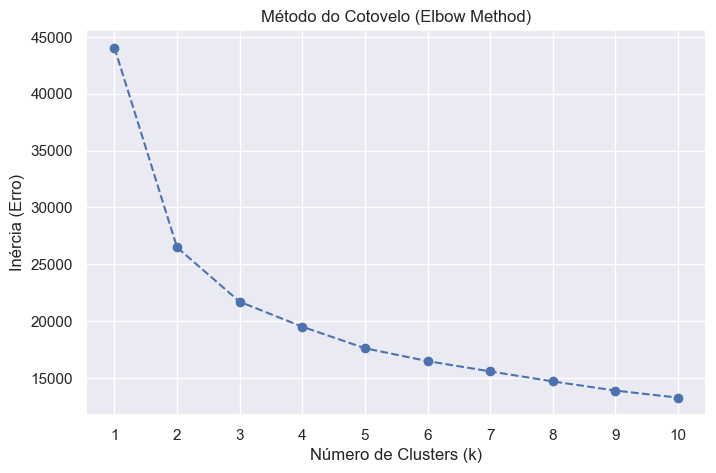

In [69]:
from sklearn.cluster import KMeans

# Vamos usar as variáveis NUMÉRICAS para agrupar fisicamente os pacientes
X_cluster = X_num_scaled 

inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 corre o algoritmo 10 vezes e escolhe o melhor, garantindo estabilidade
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Visualizar o Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Erro)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

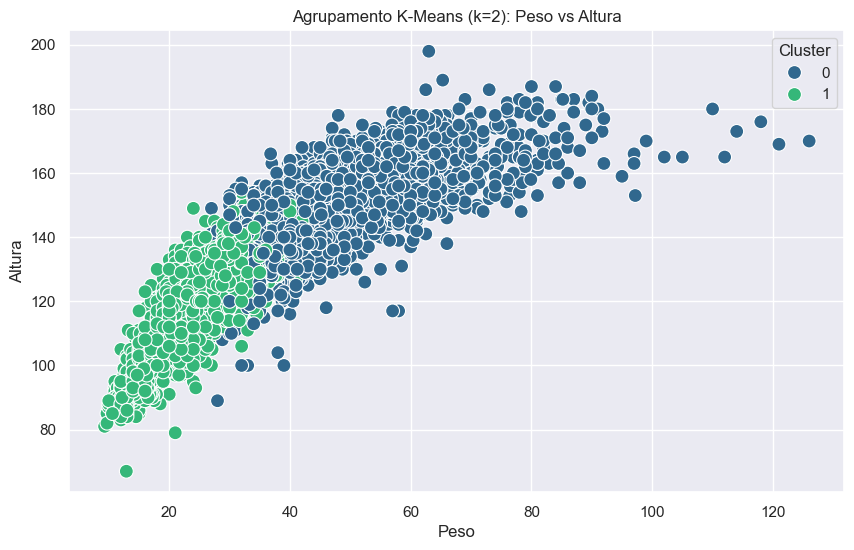

--- Perfil Médio dos Grupos Encontrados ---
              Peso      Altura        IMC      Idade         SBP        DBP  \
Cluster                                                                       
0        47.712586  149.875354  21.089790  11.644678  107.841360  66.820720   
1        22.961224  116.640241  16.658394   5.988226   96.539246  59.081894   

                FC  
Cluster             
0        80.433428  
1        88.744113  


In [76]:
k_escolhido = 2

# 1. Treinar o modelo
kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_cluster)

# 2. Adicionar os clusters ao dataframe original para podermos ler os dados
# Usamos o df_clean para ter os valores reais (não escalados)
df_results = df_clean.copy()
df_results['Cluster'] = clusters

# 3. Visualizar: Scatterplot de Peso vs Altura pintado pelo Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='Peso', y='Altura', hue='Cluster', palette='viridis', s=100)
plt.title(f'Agrupamento K-Means (k={k_escolhido}): Peso vs Altura')
plt.show()

# 4. Ver o "Perfil" médio de cada cluster
print("--- Perfil Médio dos Grupos Encontrados ---")
# Agrupamos pelo Cluster e tiramos a média das variáveis numéricas
print(df_results.groupby('Cluster')[numeric_features].mean())


--- Comparação: Os Clusters batem certo com as Doenças? ---
Patologia  Anormal  Normal
Cluster                   
0              670    1801
1             1520    2302


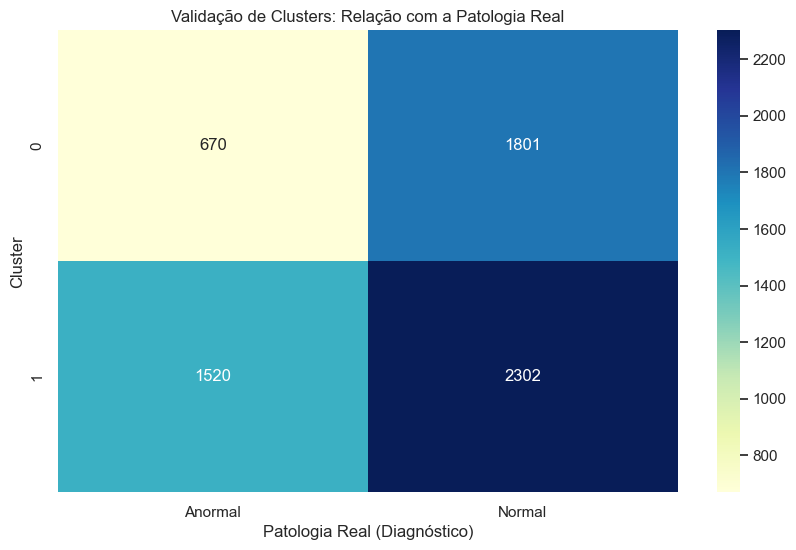

In [78]:
# Tabela de Contingência: Cluster vs Patologia Real
crosstab = pd.crosstab(df_results['Cluster'], df_results['Patologia'])

print("\n--- Comparação: Os Clusters batem certo com as Doenças? ---")
print(crosstab)

# Visualizar com Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Validação de Clusters: Relação com a Patologia Real')
plt.ylabel('Cluster')
plt.xlabel('Patologia Real (Diagnóstico)')
plt.show()

> **Conclusão:** Os clusters formados não correspondem perfeitamente às patologias. Isto indica que a doença não se manifesta exclusivamente através de alterações nas varaivies númericas, sendo necessário utilizar tambénm variáveis categoricas com informação 'clínica' (e.g. Sopro) para a distinção, tal como esta demontrado no ponto  Multiple Linear Regression.

## Predictive models

### Preparation

In [55]:
data = data.rename(columns={
    'Altura':'Altura (cm)',
    'Peso':'Peso (kg)',
    'FC':'FC (bpm)',
    'SBP':'SystolicPressure',
    'DBP' : 'DystolicPressure',
    'B2': 'Second Heart Sound (S2)',
    'HDA1': 'Current Disease History 1 (CDH1)',
    'HDA1': 'Current Disease History 2 (CDH2)',
    'Motivo1': 'Razão Principal',
    'Motivo2': 'Razão Secundária'
    })

In [56]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

## TODO: verificar se ta a fazer o enconding em condições para todas as colunas

# 1. Divisão dos Dados (Essencial para evitar Data Leakage)
# Devemos treinar os transformadores apenas no conjunto de treino
X = data.drop('Patologia', axis=1) # Exemplo: Patologia como target
y = data['Patologia']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- ESCALONAMENTO NUMÉRICO ---
# Baseado nas métricas de Peso, Altura, IMC e Pressão [cite: 26-27, 32]
num_cols = ['Peso (kg)', 'Altura (cm)', 'IMC', 'Idade', 'SystolicPressure', 'DystolicPressure', 'FC (bpm)']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
joblib.dump(scaler, 'scaler_final.joblib') # Guardar para novos exemplos 

# --- MAPEAMENTO ORDINAL (ESTÁTICO) ---
# Seguindo a hierarquia clínica da DGS e tabelas pediátricas [cite: 28-29, 64-67]
bp_map = {'Normal': 0, 'Pre-Hipertenso': 1, 'Hipertenso': 2}
imc_map = {'Baixo Peso': 0, 'Normal': 1, 'Excesso de Peso': 2, 'Obesidade': 3}

for df in [X_train, X_test]:
    df['Result SBP-DBP'] = df['Result SBP-DBP'].map(bp_map)
    df['Systolic Blood Pressure (SBP)'] = df['Systolic Blood Pressure (SBP)'].map(bp_map)
    df['Diastolic Blood Pressure (DBP)'] = df['Diastolic Blood Pressure (DBP)'].map(bp_map)
    df['Percentil IMC'] = df['Percentil IMC'].map(imc_map)

# --- ENCODING NOMINAL (ONE-HOT) ---
# Substitui o get_dummies para garantir consistência de colunas
nom_cols = ['Pulsos', 'Sopro', 'Razão Principal', 'Second Heart Sound (S2)']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[nom_cols])
X_test_ohe = ohe.transform(X_test[nom_cols])

# Criar DataFrame com as novas colunas e concatenar
ohe_df_train = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(nom_cols), index=X_train.index)
X_train = pd.concat([X_train.drop(nom_cols, axis=1), ohe_df_train], axis=1)

ohe_df_test = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(nom_cols), index=X_test.index)
X_test = pd.concat([X_test.drop(nom_cols, axis=1), ohe_df_test], axis=1)

joblib.dump(ohe, 'ohe_final.joblib') # Guardar estado das categorias

# --- LABEL ENCODING (SEXO) ---
le_sexo = LabelEncoder()
X_train['Sexo'] = le_sexo.fit_transform(X_train['Sexo'])
X_test['Sexo'] = le_sexo.transform(X_test['Sexo'])
joblib.dump(le_sexo, 'le_sexo_final.joblib')

['le_sexo_final.joblib']

### Decision Tree

### Suport Vector Machines

### Bayesian Networks

## Comparison